<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Read The data from database 
</div>

In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [17]:
conn= create_engine(
     "mysql+pymysql://root@localhost/ecommerce"
)

In [18]:
def read_query(query):
    return pd.read_sql(query,conn)

<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
     Executive Sales Dashboard
</div>

In [19]:
query="""
select * from sales
"""
print(read_query(query).columns)

Index(['transaction_id', 'customer_id', 'city', 'state', 'country', 'age',
       'gender', 'income', 'customer_segment', 'date', 'year', 'month', 'time',
       'total_purchases', 'amount', 'total_amount', 'product_category',
       'product_brand', 'feedback', 'shipping_method', 'payment_method',
       'order_status', 'ratings'],
      dtype='str')


Understand the overall business performance.

1. What is the total revenue generated?

In [20]:
query = """
SELECT SUM(total_amount) AS total_revenue
FROM sales;
"""

revenue = read_query(query)
print(f"Total Revenue: {revenue.loc[0, 'total_revenue']}")

Total Revenue: 402024952.72


2. How many total orders were placed?

In [21]:
query=""" 
select count('transaction_id') as total_order
from sales 
"""
order=read_query(query)
print(f'Total Order :{order.loc[0,'total_order']}')

Total Order :294115


3.What is the average order value (AOV)?

In [22]:
query=""" 
select avg(total_amount) as average_order_value
from sales 
"""
average= read_query(query)
print(f'Average Order Value: {average.loc[0,'average_order_value']}')

Average Order Value: 1366.897141


4. What is the average customer rating

In [23]:
query=""" 
select avg(ratings) as average_customer_rating
from sales 
"""
rating=read_query(query)
print(f"Average Customer Rating :{rating.loc[0,'average_customer_rating']}")


Average Customer Rating :3.16428


5. What is the total number of unique customers?

In [24]:
query = """
SELECT COUNT(DISTINCT customer_id) AS total_customers
FROM sales;
"""
customer = read_query(query)
print(f"Total Customers: {customer.loc[0, 'total_customers']}")

Total Customers: 86544


<div
    style="
        text-align: center;
        background-color: #4169E1;
        color: white;
        padding: 15px;
        margin: 0;
        border-radius: 15px 50px;
        font-size: 28px;
        font-family: 'Pacifico', cursive;
        font-weight: bold;
        overflow: hidden;
    "
>
    Marketing & Customer Intelligence
</div>

1. Which customer segment (customer_segment) generates the highest average revenue per transaction? 
   Is it the "Premium" segment, or are "Regular" users actually spending more per visit?

In [66]:
query = """
SELECT
    customer_segment,
    AVG(total_amount) AS average_revenue
FROM sales
GROUP BY customer_segment
ORDER BY average_revenue ASC;
"""
revenue=read_query(query)
print(revenue)

  customer_segment  average_revenue
0          Premium      1361.567210
1              New      1367.862842
2          Regular      1368.376216
3                       1531.056587


2. Which are the top 5 states or countries contributing to 80% of the company’s total revenue? Should marketing focus entirely on these regions?

In [70]:
query = """
SELECT
    state,
    SUM(total_amount) AS total_revenue,
    ROUND(
        SUM(total_amount) * 100.0 /
        (SELECT SUM(total_amount) FROM sales),
        2
    ) AS revenue_percentage
FROM sales
GROUP BY state
ORDER BY total_revenue DESC
LIMIT 5;
"""

state = read_query(query)
print(state)

             state  total_revenue  revenue_percentage
0          England    84662962.95               21.06
1           Berlin    70252028.47               17.47
2  New South Wales    60130987.23               14.96
3          Ontario    59901559.49               14.90
4      Connecticut    29005250.59                7.21


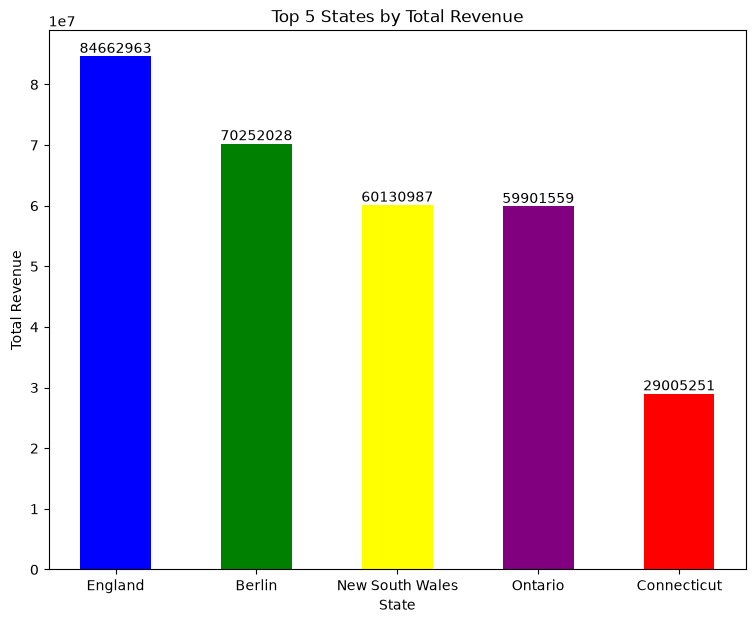

In [71]:
plt.figure(figsize=(9,7))

color = ['blue', 'green', 'yellow', 'purple', 'red']

bars = plt.bar(
    state['state'],
    state['total_revenue'],
    color=color,
    width=0.5    
)

plt.bar_label(bars, fmt='%.0f')

plt.title("Top 5 States by Total Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue")
# plt.xticks(rotation=30)

plt.show()

In [72]:
#top 5 country
query = """
SELECT
    country,
    SUM(total_amount) AS total_revenue,
    ROUND(
        SUM(total_amount) * 100.0 /
        (SELECT SUM(total_amount) FROM sales),
        2
    ) AS revenue_percentage
FROM sales
GROUP BY country
ORDER BY total_revenue DESC;
"""

country = read_query(query)
print(country)

     country  total_revenue  revenue_percentage
0        USA   1.267227e+08               31.52
1         UK   8.467449e+07               21.06
2    Germany   7.024666e+07               17.47
3  Australia   6.014346e+07               14.96
4     Canada   5.989262e+07               14.90
5              3.449732e+05                0.09


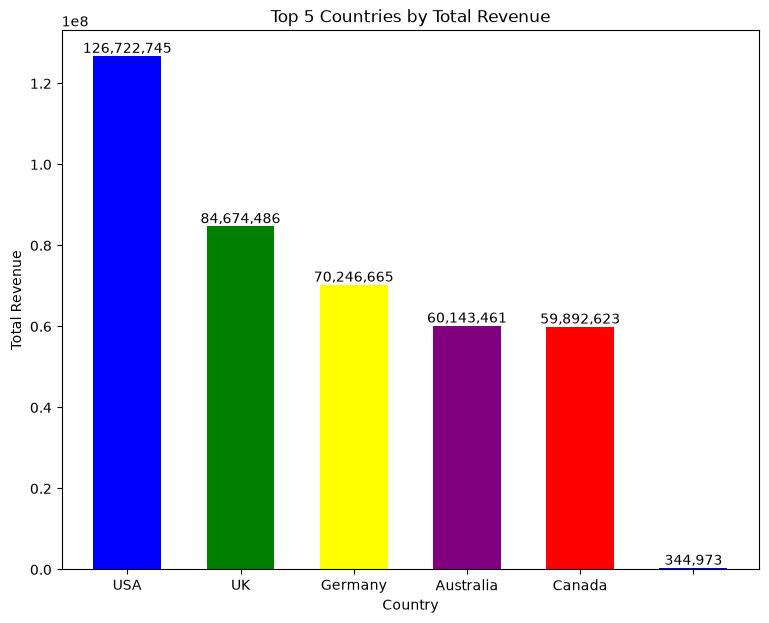

In [73]:
plt.figure(figsize=(9,7))

bar = plt.bar(
    country['country'],
    country['total_revenue'],
    width=0.6,
    color=color
)

plt.bar_label(
    bar,
    labels=[f'{x:,.0f}' for x in country['total_revenue']]
)

plt.title("Top 5 Countries by Total Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.show()

3. Do male and female customers show a statistically significant preference for different product_category? (e.g., Do women buy more "Clothing" and men more "Electronics"?)

In [82]:
query = """
SELECT
    product_category,
    SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) AS male_purchases,
    SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) AS female_purchases
FROM sales
GROUP BY product_category;
"""

products = read_query(query)
print(products)


  product_category  male_purchases  female_purchases
0                            163.0             112.0
1            Books         32461.0           20637.0
2         Clothing         32690.0           20586.0
3      Electronics         45232.0           24025.0
4          Grocery         39783.0           25271.0
5       Home Decor         32308.0           20537.0


4. If you group customers into age brackets (e.g., 18-25, 26-35, 36-50, 50+), which age bracket has the highest average spending per order, and which group makes the most total purchases?

In [89]:
query = """
SELECT
    CASE
        WHEN age BETWEEN 18 AND 25 THEN '18-25'
        WHEN age BETWEEN 26 AND 35 THEN '26-35'
        WHEN age BETWEEN 36 AND 50 THEN '36-50'
        ELSE '50+'
    END AS age_group,

    AVG(total_amount) AS average_spending,
    COUNT(*) AS total_purchases

FROM sales
GROUP BY age_group
ORDER BY average_spending DESC;
"""

customers = read_query(query)
print(customers)

  age_group  average_spending  total_purchases
0       50+       1396.803872            52522
1     36-50       1389.728523            67047
2     26-35       1377.723059            64356
3     18-25       1332.427137           110190


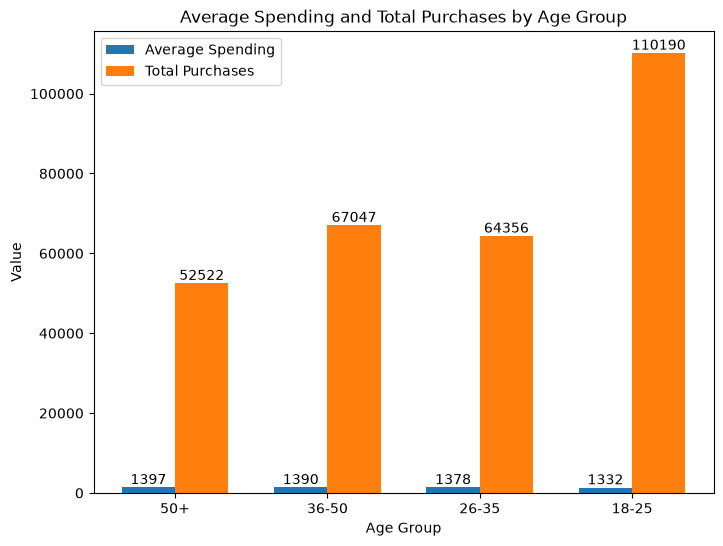

In [ ]:


x = np.arange(len(customers['age_group']))
width = 0.35
plt.figure(figsize=(8,6))
bar1 = plt.bar(x - width/2, customers['average_spending'],
               width, label='Average Spending')
bar2 = plt.bar(x + width/2, customers['total_purchases'],
               width, label='Total Purchases')
plt.xticks(x, customers['age_group'])
plt.bar_label(bar1, fmt='%.0f')
plt.bar_label(bar2)
plt.title("Average Spending and Total Purchases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Value")
plt.legend()
plt.show()